# Experiment with multilinear fusion model

In [1]:
import sys
import warnings
import math as m
import numpy as np
import pandas as pd
import tensorly as tl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from tqdm import tqdm
import plotly.graph_objs as go

from sklearn.decomposition import PCA, KernelPCA
from statsmodels.tsa.stattools import acf

import scipy
from scipy.linalg import hankel
from scipy.signal import find_peaks
from scipy.spatial import distance_matrix
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.nn.parameter import Parameter
from torch.nn.init import xavier_normal_, xavier_uniform_

sys.path.append('./../')
from tensordynamicmodel.visuals import plot_phase_trajectory, delay_embedding_matrix
from tensordynamicmodel.utils import delay_embedding_matrix, diag_mean, prepare_time_series, lorenz

In [2]:
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams.update({"text.usetex": False})

torch.manual_seed(123)

In [3]:
class InitPhaseAE(nn.Module):

    def __init__(self, x_dims, rank, attractor_dim):
        
        super(InitPhaseAE, self).__init__()
        
        self.x_dims = x_dims
        self.rank = rank #not used
        self.attractor_dim = attractor_dim
        self.all_dims = np.sum(np.array(x_dims))
        
        self.model_encoder = nn.Sequential(
                nn.Linear(self.all_dims, self.all_dims),
                nn.ReLU(),
                nn.Linear(self.all_dims, self.attractor_dim),
                nn.ReLU(),
                nn.Linear(self.attractor_dim, self.attractor_dim)
            )

        self.model_decoder = nn.Sequential(
                nn.Linear(self.attractor_dim, self.attractor_dim),
                nn.ReLU(),
                nn.Linear(self.attractor_dim, self.all_dims),
                nn.ReLU(),
                nn.Linear(self.all_dims, self.all_dims),
            )

    def encoder(self, Xs):
        concat_X = torch.cat(Xs, 1)
        S = self.model_encoder(concat_X)
        return S
    
    def transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        S = self.encoder(Xs).detach().cpu().numpy()
        return S
    
    def decoder(self, S):
        concat_pred_X = self.model_decoder(S)
        pred_Xs = torch.split(concat_pred_X,self.x_dims,1)
        return pred_Xs
    
    def inverse_transform(self, S):
        S = torch.from_numpy(S).to(torch.float)
        concat_pred_X = self.model_decoder(S)
        pred_Xs = torch.split(concat_pred_X,self.x_dims,1)
        pred_Xs = [X.detach().cpu().numpy() for X in pred_Xs]
        return pred_Xs
        
    def forward(self, Xs):
        S = self.encoder(Xs)
        pred_Xs = self.decoder(S)
        return pred_Xs

In [4]:
class HiddenPhaseAE(nn.Module):

    def __init__(self, x_dims, rank, attractor_dim):
        super(HiddenPhaseAE, self).__init__()
        self.x_dims = x_dims
        self.rank = rank
        self.attractor_dim = attractor_dim
        self.cocncat_attractor_dim = int(attractor_dim*len(x_dims))
        
        
        self.nn_model_encoder = [
            nn.Sequential(
                nn.Linear(dims, dims),
                nn.ReLU(),
                nn.Linear(dims, self.attractor_dim),
                nn.ReLU()
            )
            for dims in x_dims
        ]
        
        self.nn_model_decoder = [
            nn.Sequential(
                nn.Linear(self.attractor_dim, self.attractor_dim),
                nn.ReLU(),
                nn.Linear(self.attractor_dim, dims),
                nn.ReLU(),
                nn.Linear(dims, dims)
            )
            for dims in x_dims
        ]
        
        self.cocncat_model = nn.Sequential(
                nn.Linear(self.cocncat_attractor_dim, self.cocncat_attractor_dim),
                nn.ReLU(),
                nn.Linear(self.cocncat_attractor_dim, self.attractor_dim)
        )

    def encoder(self, Xs):
        Hs = [en_model(Xs[i]) for i, en_model in enumerate(self.nn_model_encoder)]
        concat_H = torch.cat(Hs, 1)
        S = self.cocncat_model(concat_H)
        return S
    
    def transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        Hs = [en_model(Xs[i]) for i, en_model in enumerate(self.nn_model_encoder)]
        concat_H = torch.cat(Hs, 1)
        S = self.cocncat_model(concat_H)
        S = S.detach().cpu().numpy() 
        return S

    def decoder(self, S):
        pred_Xs = [de_model(S) for de_model in self.nn_model_decoder]
        return pred_Xs
    
    def inverse_transform(self, S):
        S = torch.from_numpy(S).to(torch.float)
        pred_Xs = [de_model(S) for de_model in self.nn_model_decoder]
        pred_Xs = [X.detach().cpu().numpy() for X in pred_Xs]
        return pred_Xs
        
    def forward(self, Xs):
        S = self.encoder(Xs)
        pred_Xs = self.decoder(S)
        return pred_Xs

In [27]:
class MultilinearHiddenPhaseAE(nn.Module):
    def __init__(self, x_dims, rank, attractor_dim):
        super(MultilinearHiddenPhaseAE, self).__init__()
        self.x_dims = x_dims
        self.rank = rank
        self.attractor_dim = attractor_dim
        self.cocncat_attractor_dim = int(attractor_dim*len(x_dims))
        
        
        self.nn_model_encoder = [
            nn.Sequential(
                nn.Linear(dims, dims),
                nn.ReLU(),
                nn.Linear(dims, attractor_dim),
                nn.ReLU(),
                nn.Linear(attractor_dim, self.rank)
            )
            for dims in x_dims
        ]
        
        self.nn_model_decoder = [
            nn.Sequential(
                nn.Linear(attractor_dim, dims),
                nn.ReLU(),
                nn.Linear(dims, dims),
                nn.ReLU()
            )
            for dims in x_dims
        ]


        self.cocncat_model = nn.Sequential(
                nn.Linear(self.rank, self.attractor_dim)
        )

    def encoder(self, Xs):
        hidden_Xs_rank = [en_model(Xs[i]) for i, en_model in enumerate(self.nn_model_encoder)]
        hidden_X = 1
        for i in range(len(self.x_dims)):
            hidden_X *= hidden_Xs_rank[i]
        S = self.cocncat_model(hidden_X)
        return S
    
    
    def transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        S = self.encoder(Xs).detach().cpu().numpy()
        return S
    
    def decoder(self, S):
        pred_Xs = [de_model(S) for de_model in self.nn_model_decoder]
        return pred_Xs
    
    def inverse_transform(self, S):
        S = torch.from_numpy(S).to(torch.float)
        pred_Xs = [de_model(S) for de_model in self.nn_model_decoder]
        pred_Xs = [X.detach().cpu().numpy() for X in pred_Xs]
        return pred_Xs
        
    def forward(self, Xs):
        S = self.encoder(Xs)
        pred_Xs = self.decoder(S)
        return pred_Xs

In [28]:
def make_ts(person, activity):
    pdf_data_all = pd.read_csv(f'./../data/A_DeviceMotion_data/{activity}/sub_{person}.csv').reset_index(drop=True)
    data_list = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    data_list_short = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    mean = pdf_data_all[data_list].mean()
    var = pdf_data_all[data_list].var()**.5
    pdf_data_all[data_list] = (pdf_data_all[data_list]-mean)/var
    pdf_data_all = pdf_data_all[data_list_short]
    xyz = pdf_data_all[data_list_short].to_numpy()
    x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]
    return x,y,z

In [29]:
def fit_torch_model(Xs, model):
    model.train()
    optimizer = optim.Adam(model.parameters())
    epoch = 10_000 
    loss_function = nn.MSELoss()
    Xs = [torch.from_numpy(x).to(torch.float) for x in Xs]
    for i in range(epoch):
        loss = 0
        pred_Xs = model(Xs)
        for X, pred_X in zip(Xs, pred_Xs):
            loss += loss_function(X, pred_X)
            
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    model.eval()
    return model

# Attractor examples

In [30]:
person = 1
activity = 'jog_16'
# activity = 'wlk_7'

freq_n = 1
lag = 30

attractor_dim = 3
rank = 30

In [31]:
# x, y, z = make_ts(person, activity)
x = np.sin(np.linspace(0,650,5000))+np.random.rand(5000)*0.5
y = np.cos(np.linspace(0,650,5000))+np.random.rand(5000)*0.5
z = np.sin(np.linspace(0,650,5000)+10)+np.random.rand(5000)*0.5

Xs = [
    delay_embedding_matrix(x, lag, fit_intercept=False)[:,::freq_n],
    delay_embedding_matrix(y, lag, fit_intercept=False)[:,::freq_n],
    delay_embedding_matrix(z, lag, fit_intercept=False)[:,::freq_n]
]
x_dims = [x.shape[1] for x in Xs] 
x_dims, Xs[0].shape

([30, 30, 30], (4971, 30))

(-5.0, 5.0)

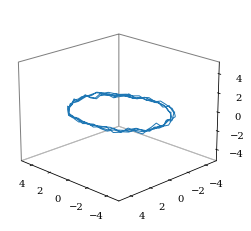

In [32]:
ax = plot_phase_trajectory(PCA(3).fit_transform(np.concatenate(Xs))[:200,:], rotation=(0, 0, 0))
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.set_zlim(-5,5)

## Init phase space concatenation

In [33]:
model_1 = InitPhaseAE(x_dims, rank, attractor_dim)
print(model_1)

InitPhaseAE(
  (model_encoder): Sequential(
    (0): Linear(in_features=90, out_features=90, bias=True)
    (1): ReLU()
    (2): Linear(in_features=90, out_features=3, bias=True)
    (3): ReLU()
    (4): Linear(in_features=3, out_features=3, bias=True)
  )
  (model_decoder): Sequential(
    (0): Linear(in_features=3, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=90, bias=True)
    (3): ReLU()
    (4): Linear(in_features=90, out_features=90, bias=True)
  )
)


In [34]:
model_1 = fit_torch_model(Xs, model_1)

In [35]:
S = model_1.transform(Xs)

<Axes3DSubplot:>

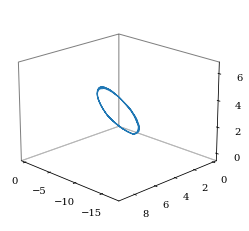

In [36]:
plot_phase_trajectory(S[:200,:], rotation=(0, 0, 0),)

## Hidden linear  phase space concatenation

In [37]:
model_2 = HiddenPhaseAE(x_dims, rank, attractor_dim)

In [38]:
model_2 = fit_torch_model(Xs, model_2)

In [39]:
S = model_2.transform(Xs)

<Axes3DSubplot:>

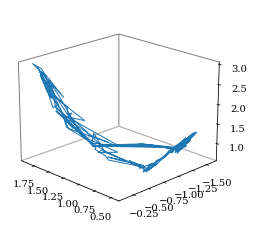

In [40]:
plot_phase_trajectory(S[:200,:])

## Hidden multilinear phase space concatenation

In [41]:
model_3 = MultilinearHiddenPhaseAE(x_dims, rank, attractor_dim)
model_3 = fit_torch_model(Xs, model_3)

<Axes3DSubplot:>

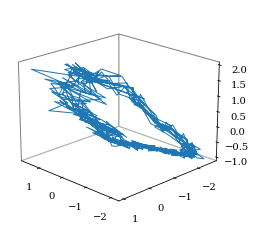

In [42]:
S = model_3.transform(Xs)
plot_phase_trajectory(S[:500,:])

# Experiment over all person

In [ ]:
def make_experiment_xy_z(activity, lag):
    result_tables_model_names = [
        'person',
        'Init Phase',
        'Hidden Linear Phase',
        'Hidden Multilinear Phase'
    ] 
    rank = 10
    
    pdf_r2_train_ts = pd.DataFrame(columns=result_tables_model_names)
    pdf_mse_train_ts = pd.DataFrame(columns=result_tables_model_names)
    
#     for person in tqdm([1, 2, 4, 5, 6, 7, 8, 9, 11, 12]):
    for person in [1, 2]:
        
        x, y, z = make_ts(person, activity)
        if x.shape[0] <= 650:
            continue
    
        Xs_tde = [
            delay_embedding_matrix(x, lag, fit_intercept=False)[:,::freq_n],
            delay_embedding_matrix(y, lag, fit_intercept=False)[:,::freq_n],
            delay_embedding_matrix(z, lag, fit_intercept=False)[:,::freq_n]
        ]
        x_dims = [x.shape[1] for x in Xs_tde] 
        
        for dim_n in  tqdm(np.arange(2,7)):
            _pdf_r2_train_ts = pd.DataFrame(columns=result_tables_model_names)
            _pdf_mse_train_ts = pd.DataFrame(columns=result_tables_model_names)
    
            # Make state space reconstruction models
            model_init_phase = InitPhaseAE(x_dims, rank, dim_n)
            model_hidden_phase = HiddenPhaseAE(x_dims, rank, dim_n)
            model_tensor_phase = MultilinearHiddenPhaseAE(x_dims, rank, dim_n)
            
            models = [model_init_phase, model_hidden_phase, model_tensor_phase]
            model = [ fit_torch_model(Xs_tde, model) for model in models]
            
            list_S = [model.transform(Xs_tde) for model in models]
            
            list_pred_X = [model.inverse_transform(S) for S, model in zip(list_S, models)]
            
            # Resore initial time series
            xyz_true = np.concatenate(Xs_tde,1)
            xyz_rec = [np.concatenate(X,1) for X in list_pred_X]
            
            
            _pdf_r2_train_ts.loc[dim_n, :] = [person]+[r2_score(xyz_true, xyz) for xyz in xyz_rec]
            _pdf_mse_train_ts.loc[dim_n, :] = [person]+[mse(xyz_true, xyz)**.5 for xyz in xyz_rec]

            pdf_r2_train_ts = pd.concat([pdf_r2_train_ts, _pdf_r2_train_ts], axis=0)
            pdf_mse_train_ts = pd.concat([pdf_mse_train_ts, _pdf_mse_train_ts], axis=0)

    return pdf_r2_train_ts, pdf_mse_train_ts

In [ ]:
list_all_exp = make_experiment_xy_z('wlk_7', 15)

In [ ]:
list_all_exp

In [ ]:
list_activities = [
#     'dws_11',
    # 'ups_3', 'wlk_15',
    
    # 'dws_1', 'dws_2',
    # 'jog_16', 'jog_9',
    # 'sit_13', 'sit_5',
    # 'std_14', 'std_6',
    # 'ups_12', 'ups_4',
    'wlk_7',
    # 'wlk_8'.
]

for name, exp_act in zip(list_activities, [list_all_exp]):
    fig, axs = plt.subplots(1,2,figsize=(20,3))
    _ = [DF.drop(columns=['person']).reset_index().groupby('index').mean().plot(ax=ax) for DF, ax in zip(exp_act, axs)]
    _ = [ax.set_ylim(0,1) for ax in axs]
    fig.suptitle(name, fontsize=20)

In [ ]:
freq_n = 1
list_all_exp = []
list_activities = [
#     'dws_11',
    # 'ups_3', 'wlk_15',
    
    # 'dws_1', 'dws_2',
    # 'jog_16', 'jog_9',
    # 'sit_13', 'sit_5',
    # 'std_14', 'std_6',
    # 'ups_12', 'ups_4',
    'wlk_7',
    # 'wlk_8'.
]

list_all_exp = [make_experiment_xy_z(activity, 15) for activity in list_activities]

In [ ]:
for name, exp_act in zip(list_activities, list_all_exp):
    fig, axs = plt.subplots(1,2,figsize=(20,3))
    _ = [DF.drop(columns=['person']).reset_index().groupby('index').mean().plot(ax=ax) for DF, ax in zip(exp_act, axs)]
    _ = [ax.set_ylim(0,1) for ax in axs]
    fig.suptitle(name, fontsize=20)

Генерация временных рядов...
Создание модели...
Модель создана:
Количество параметров: 14102
Латентная размерность: 8
Начало обучения...
Epoch [20/150], Loss: 2.126871
Epoch [40/150], Loss: 2.084700
Epoch [60/150], Loss: 2.076026
Epoch [80/150], Loss: 2.033592
Epoch [100/150], Loss: 1.923317
Epoch [120/150], Loss: 1.923575
Epoch [140/150], Loss: 1.924403


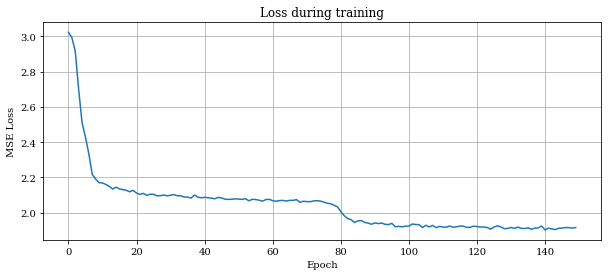

Визуализация результатов...


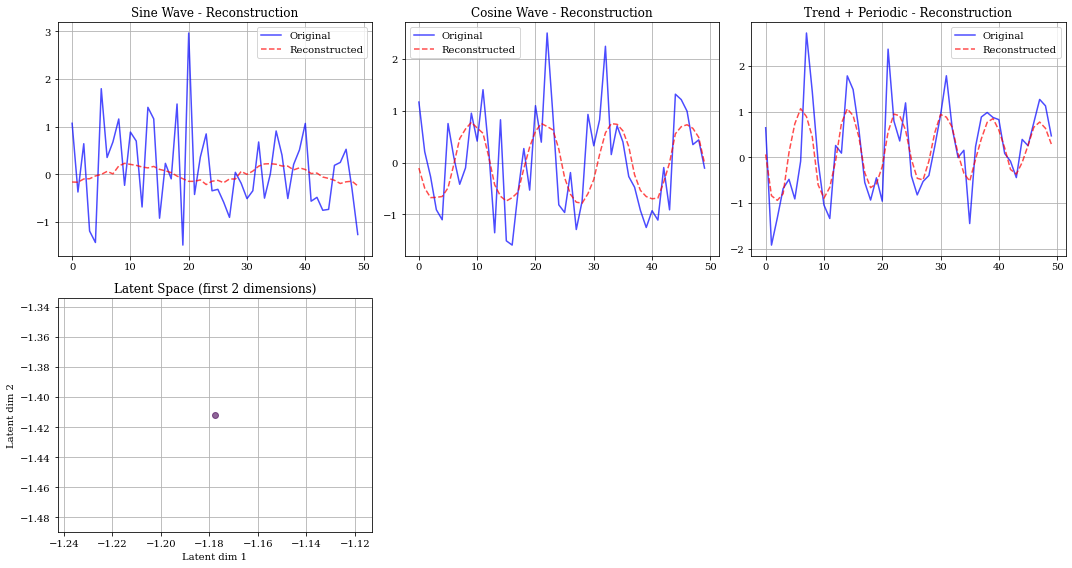


Анализ латентного пространства:
Размер латентных представлений: torch.Size([160, 8])
Среднее значение по латентным измерениям: tensor([-0.3473, -0.2134, -0.0540, -0.1931])
Стандартное отклонение: tensor([1.1755, 1.5181, 0.7592, 1.3590])


In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

# Генерация простых временных рядов для эксперимента
def generate_time_series(num_series=3, length=100, samples=1000):
    """
    Генерация нескольких временных рядов
    """
    np.random.seed(42)
    time = np.linspace(0, 4*np.pi, length)
    
    series_data = []
    
    for i in range(num_series):
        # Генерация разных паттернов для каждого ряда
        if i == 0:
            # Синусоида с шумом
            data = np.sin(time + np.random.normal(0, 0.1, samples)[:, None]) + \
                   np.random.normal(0, 0.1, (samples, length))
        elif i == 1:
            # Косинусоида с шумом
            data = np.cos(2*time + np.random.normal(0, 0.1, samples)[:, None]) + \
                   np.random.normal(0, 0.1, (samples, length))
        else:
            # Линейный тренд + периодическая компонента
            trend = np.linspace(0, 1, length) * np.random.normal(1, 0.2, samples)[:, None]
            periodic = np.sin(3*time) * np.random.normal(1, 0.1, samples)[:, None]
            data = trend + periodic + np.random.normal(0, 0.1, (samples, length))
        
        series_data.append(data)
    
    return series_data

# Автоэнкодер с отдельными подсетями для каждого временного ряда
class MultiTimeSeriesAutoencoder(nn.Module):
    def __init__(self, series_lengths, hidden_dims=[64, 32], latent_dim=16):
        """
        Args:
            series_lengths: список длин каждого временного ряда
            hidden_dims: размеры скрытых слоев энкодера
            latent_dim: размер латентного пространства
        """
        super(MultiTimeSeriesAutoencoder, self).__init__()
        
        self.num_series = len(series_lengths)
        self.series_lengths = series_lengths
        self.latent_dim = latent_dim
        
        # Энкодеры для каждого временного ряда
        self.encoders = nn.ModuleList()
        for length in series_lengths:
            encoder_layers = []
            input_dim = length
            
            for hidden_dim in hidden_dims:
                encoder_layers.extend([
                    nn.Linear(input_dim, hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(0.2)
                ])
                input_dim = hidden_dim
            
            encoder_layers.append(nn.Linear(input_dim, latent_dim))
            self.encoders.append(nn.Sequential(*encoder_layers))
        
        # Полилинейное отображение для объединения представлений
        self.fusion_layer = nn.Linear(self.num_series * latent_dim, latent_dim)
        
        # Декодеры для каждого временного ряда
        self.decoders = nn.ModuleList()
        for length in series_lengths:
            decoder_layers = []
            input_dim = latent_dim
            
            for hidden_dim in reversed(hidden_dims):
                decoder_layers.extend([
                    nn.Linear(input_dim, hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(0.2)
                ])
                input_dim = hidden_dim
            
            decoder_layers.append(nn.Linear(input_dim, length))
            self.decoders.append(nn.Sequential(*decoder_layers))
    
    def encode(self, x_list):
        """
        Кодирование каждого временного ряда
        """
        encoded_list = []
        for i, x in enumerate(x_list):
            encoded = self.encoders[i](x)
            encoded_list.append(encoded)
        
        # Объединение представлений через полилинейное отображение
        combined = torch.cat(encoded_list, dim=1)
        latent = self.fusion_layer(combined)
        
        return latent, encoded_list
    
    def decode(self, latent):
        """
        Декодирование из общего латентного пространства
        """
        decoded_list = []
        for i in range(self.num_series):
            decoded = self.decoders[i](latent)
            decoded_list.append(decoded)
        
        return decoded_list
    
    def forward(self, x_list):
        latent, individual_encodings = self.encode(x_list)
        reconstructions = self.decode(latent)
        return reconstructions, latent, individual_encodings

# Функция для обучения модели
def train_model(model, dataloaders, num_epochs=100, learning_rate=0.001):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    train_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        num_batches = 0
        
        for batch in zip(*[dataloaders[i] for i in range(len(dataloaders))]):
            # Извлекаем батчи для каждого временного ряда
            batch_data = []
            for i, (data, _) in enumerate(batch):
                batch_data.append(data)
            
            optimizer.zero_grad()
            
            # Прямой проход
            reconstructions, _, _ = model(batch_data)
            
            # Вычисление потерь для каждого ряда
            loss = 0
            for i in range(len(reconstructions)):
                loss += criterion(reconstructions[i], batch_data[i])
            
            # Обратный проход
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
        
        avg_loss = total_loss / num_batches
        train_losses.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')
    
    return train_losses

# Визуализация результатов
def visualize_results(model, test_data, original_data, series_names):
    model.eval()
    with torch.no_grad():
        reconstructions, latent, _ = model(test_data)
    
    fig, axes = plt.subplots(2, len(series_names), figsize=(15, 8))
    
    for i in range(len(series_names)):
        # Оригинальные данные
        axes[0, i].plot(original_data[i][0], 'b-', alpha=0.7, label='Original')
        axes[0, i].plot(reconstructions[i][0].numpy(), 'r--', alpha=0.7, label='Reconstructed')
        axes[0, i].set_title(f'{series_names[i]} - Reconstruction')
        axes[0, i].legend()
        axes[0, i].grid(True)
        
        # Все примеры в латентном пространстве
        if i == 0:
            axes[1, i].scatter(latent[:, 0].numpy(), latent[:, 1].numpy(), 
                              alpha=0.6, c=range(len(latent)), cmap='viridis')
            axes[1, i].set_title('Latent Space (first 2 dimensions)')
            axes[1, i].set_xlabel('Latent dim 1')
            axes[1, i].set_ylabel('Latent dim 2')
            axes[1, i].grid(True)
        else:
            axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Основной эксперимент
def main():
    # Параметры эксперимента
    num_series = 3
    series_length = 50
    num_samples = 800
    batch_size = 32
    latent_dim = 8
    
    print("Генерация временных рядов...")
    # Генерация данных
    series_data = generate_time_series(num_series, series_length, num_samples)
    series_names = ['Sine Wave', 'Cosine Wave', 'Trend + Periodic']
    
    # Нормализация данных
    scalers = []
    normalized_data = []
    
    for i, data in enumerate(series_data):
        scaler = StandardScaler()
        normalized = scaler.fit_transform(data)
        normalized_data.append(normalized)
        scalers.append(scaler)
    
    # Разделение на train/test
    split_idx = int(0.8 * num_samples)
    
    train_data = []
    test_data = []
    original_test = []
    
    for i in range(num_series):
        train_tensor = torch.FloatTensor(normalized_data[i][:split_idx])
        test_tensor = torch.FloatTensor(normalized_data[i][split_idx:])
        
        train_dataset = TensorDataset(train_tensor, train_tensor)
        test_dataset = TensorDataset(test_tensor, test_tensor)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        
        train_data.append(train_loader)
        test_data.append(test_loader)
        
        # Сохраняем оригинальные данные для визуализации
        original_test.append(normalized_data[i][split_idx:split_idx+1])
    
    # Создание модели
    print("Создание модели...")
    model = MultiTimeSeriesAutoencoder(
        series_lengths=[series_length] * num_series,
        hidden_dims=[32, 16],
        latent_dim=latent_dim
    )
    
    print(f"Модель создана:")
    print(f"Количество параметров: {sum(p.numel() for p in model.parameters())}")
    print(f"Латентная размерность: {latent_dim}")
    
    # Обучение модели
    print("Начало обучения...")
    losses = train_model(model, train_data, num_epochs=150, learning_rate=0.001)
    
    # Визуализация обучения
    plt.figure(figsize=(10, 4))
    plt.plot(losses)
    plt.title('Loss during training')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True)
    plt.show()
    
    # Подготовка тестовых данных для визуализации
    test_tensors = []
    for i in range(num_series):
        test_tensors.append(torch.FloatTensor(original_test[i]))
    
    # Визуализация результатов
    print("Визуализация результатов...")
    visualize_results(model, test_tensors, original_test, series_names)
    
    # Анализ латентного пространства
    model.eval()
    with torch.no_grad():
        # Получаем латентные представления для всех тестовых данных
        all_latent = []
        for batch in zip(*test_data):
            batch_tensors = [data for data, _ in batch]
            _, latent, _ = model(batch_tensors)
            all_latent.append(latent)
        
        all_latent = torch.cat(all_latent, dim=0)
        
        print(f"\nАнализ латентного пространства:")
        print(f"Размер латентных представлений: {all_latent.shape}")
        print(f"Среднее значение по латентным измерениям: {all_latent.mean(dim=0)[:4]}")
        print(f"Стандартное отклонение: {all_latent.std(dim=0)[:4]}")
    
    return model, scalers

if __name__ == "__main__":
    model, scalers = main()

Генерация временных рядов...
Нормализация данных...
Ряд 1: mean=-0.000, std=1.000
Ряд 2: mean=0.000, std=1.000
Ряд 3: mean=0.000, std=1.000

Разделение данных:
Обучающая выборка: 800 примеров
Тестовая выборка: 200 примеров

Создание модели с каноническим разложением...
Архитектура модели:
Количество параметров: 16,038
Латентная размерность: 16
Ранг канонического разложения: 8

Начало обучения...
Epoch [20/100], Loss: 0.759098
Epoch [40/100], Loss: 0.711528
Epoch [60/100], Loss: 0.695278
Epoch [80/100], Loss: 0.720924
Epoch [100/100], Loss: 0.708721


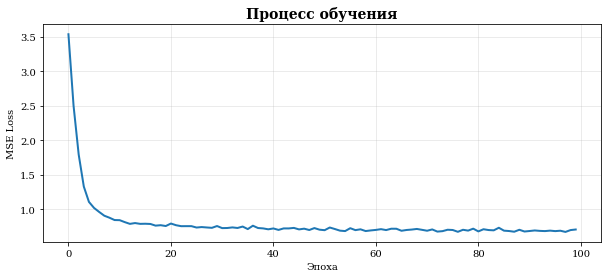


АНАЛИЗ КАНОНИЧЕСКОГО РАЗЛОЖЕНИЯ
Ранг разложения: 8
Количество временных рядов: 3

Факторы канонического разложения:
Фактор 1: форма torch.Size([16, 8]), норма: 3.2350
  Сингулярные значения: [1.7188036 1.5706786 1.3319464]
Фактор 2: форма torch.Size([16, 8]), норма: 3.0403
  Сингулярные значения: [1.5939984 1.2905362 1.2436185]
Фактор 3: форма torch.Size([16, 8]), норма: 3.2121
  Сингулярные значения: [1.6639264 1.5076157 1.2940737]

Ядро разложения: форма torch.Size([8, 3, 16]), норма: 2.1538

Визуализация результатов...


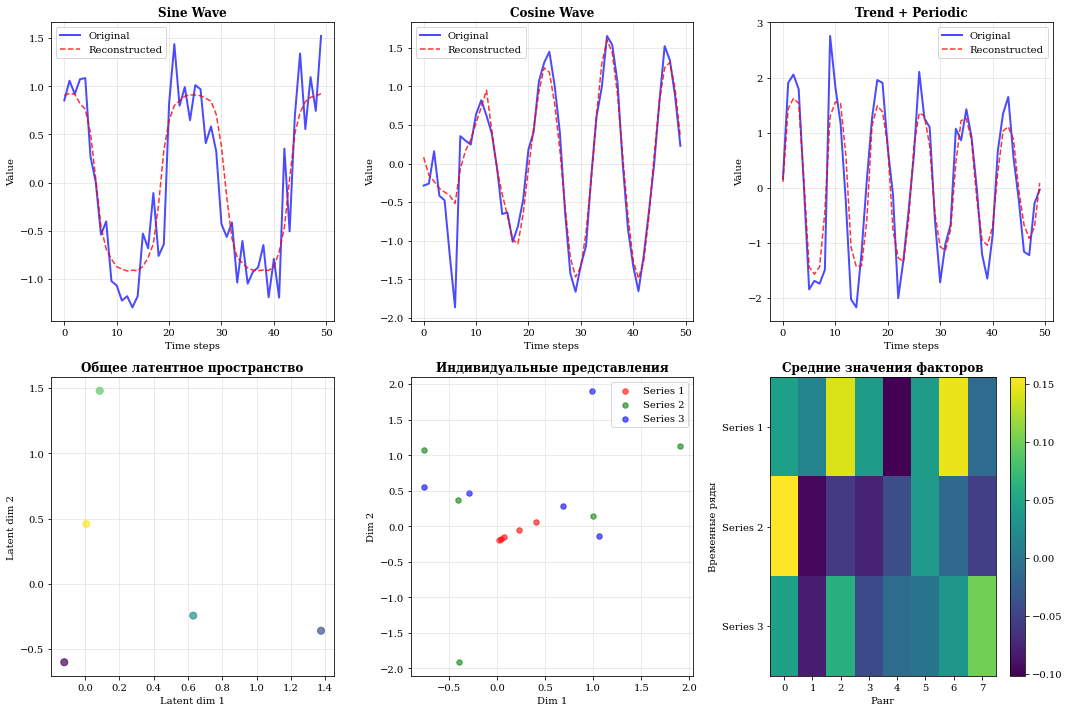


Проведение эксперимента с разными рангами...

ЭКСПЕРИМЕНТ С РАЗНЫМИ РАНГАМИ

--- Обучение с рангом 2 ---
Epoch [20/80], Loss: 0.868801
Epoch [40/80], Loss: 0.783866
Epoch [60/80], Loss: 0.771384
Epoch [80/80], Loss: 0.727726
Финальная потеря: 0.727726
Количество параметров: 15462

--- Обучение с рангом 4 ---
Epoch [20/80], Loss: 0.798128
Epoch [40/80], Loss: 0.708549
Epoch [60/80], Loss: 0.724637
Epoch [80/80], Loss: 0.676303
Финальная потеря: 0.676303
Количество параметров: 15654

--- Обучение с рангом 8 ---
Epoch [20/80], Loss: 0.780618
Epoch [40/80], Loss: 0.743382
Epoch [60/80], Loss: 0.709069
Epoch [80/80], Loss: 0.707360
Финальная потеря: 0.707360
Количество параметров: 16038

--- Обучение с рангом 16 ---
Epoch [20/80], Loss: 0.778053
Epoch [40/80], Loss: 0.706837
Epoch [60/80], Loss: 0.696183
Epoch [80/80], Loss: 0.689668
Финальная потеря: 0.689668
Количество параметров: 16806


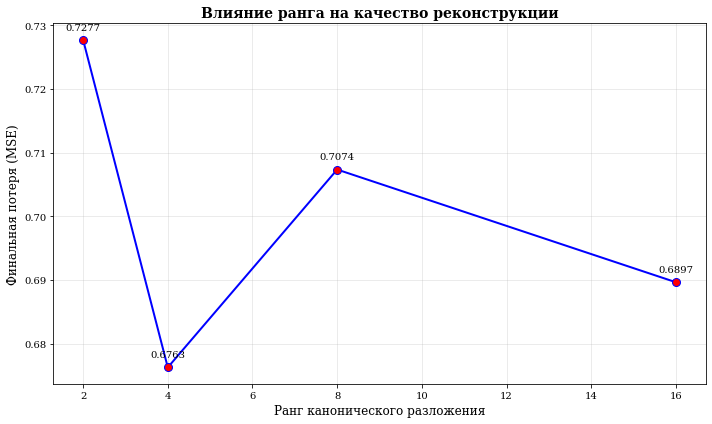


ТЕСТИРОВАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ
Потеря для ряда 'Sine Wave': 0.134768
Потеря для ряда 'Cosine Wave': 0.095953
Потеря для ряда 'Trend + Periodic': 0.240934

Общая тестовая потеря: 0.471654


In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Генерация простых временных рядов для эксперимента
def generate_time_series(num_series=3, length=100, samples=1000):
    """
    Генерация нескольких временных рядов
    """
    np.random.seed(42)
    time = np.linspace(0, 4*np.pi, length)
    
    series_data = []
    
    for i in range(num_series):
        # Генерация разных паттернов для каждого ряда
        if i == 0:
            # Синусоида с шумом
            phase_shift = np.random.normal(0, 0.5, samples)[:, None]
            data = np.sin(time + phase_shift) + np.random.normal(0, 0.1, (samples, length))
        elif i == 1:
            # Косинусоида с разной частотой
            freq_multiplier = np.random.uniform(1.5, 2.5, samples)[:, None]
            data = np.cos(freq_multiplier * time) + np.random.normal(0, 0.1, (samples, length))
        else:
            # Линейный тренд + периодическая компонента
            trend_slope = np.random.uniform(0.5, 1.5, samples)[:, None]
            trend = trend_slope * np.linspace(0, 1, length)
            periodic = np.sin(3 * time) * np.random.normal(1, 0.2, samples)[:, None]
            data = trend + periodic + np.random.normal(0, 0.1, (samples, length))
        
        series_data.append(data.astype(np.float32))
    
    return series_data

# Слой канонического разложения для полилинейного отображения
class CanonicalFusionLayer(nn.Module):
    def __init__(self, num_series, input_dim, output_dim, rank):
        """
        Args:
            num_series: количество временных рядов
            input_dim: размерность входных представлений для каждого ряда
            output_dim: размерность выходного представления
            rank: ранг канонического разложения
        """
        super(CanonicalFusionLayer, self).__init__()
        
        self.num_series = num_series
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.rank = rank
        
        # Факторы канонического разложения для каждого ряда
        self.factors = nn.ParameterList([
            nn.Parameter(torch.randn(input_dim, rank)) for _ in range(num_series)
        ])
        
        # Ядро разложения
        self.core_tensor = nn.Parameter(torch.randn(rank, num_series, output_dim))
        
        # Инициализация
        for factor in self.factors:
            nn.init.xavier_uniform_(factor)
        nn.init.xavier_uniform_(self.core_tensor)
        
    def forward(self, encoded_list):
        """
        Применение канонического разложения к списку представлений
        
        Args:
            encoded_list: список тензоров формы [batch_size, input_dim]
            
        Returns:
            Объединенное представление формы [batch_size, output_dim]
        """
        batch_size = encoded_list[0].size(0)
        
        # Применяем факторы к каждому представлению
        projected = []
        for i, encoded in enumerate(encoded_list):
            # [batch_size, input_dim] x [input_dim, rank] -> [batch_size, rank]
            proj = torch.matmul(encoded, self.factors[i])
            projected.append(proj)
        
        # Собираем проекции в тензор [batch_size, rank, num_series]
        projected_tensor = torch.stack(projected, dim=2)
        
        # Применяем ядро разложения
        output = torch.einsum('brs,rsd->bd', projected_tensor, self.core_tensor)
        
        return output

# Автоэнкодер с каноническим разложением
class CanonicalAutoencoder(nn.Module):
    def __init__(self, series_lengths, hidden_dims=[64, 32], latent_dim=16, rank=8):
        """
        Args:
            series_lengths: список длин каждого временного ряда
            hidden_dims: размеры скрытых слоев энкодера
            latent_dim: размер латентного пространства
            rank: ранг канонического разложения
        """
        super(CanonicalAutoencoder, self).__init__()
        
        self.num_series = len(series_lengths)
        self.series_lengths = series_lengths
        self.latent_dim = latent_dim
        self.rank = rank
        
        # Энкодеры для каждого временного ряда
        self.encoders = nn.ModuleList()
        encoder_output_dims = []
        
        for length in series_lengths:
            encoder_layers = []
            input_dim = length
            
            for hidden_dim in hidden_dims:
                encoder_layers.extend([
                    nn.Linear(input_dim, hidden_dim),
                    nn.ReLU(),
                    nn.BatchNorm1d(hidden_dim),
                    nn.Dropout(0.1)
                ])
                input_dim = hidden_dim
            
            # Последний слой энкодера
            encoder_output_dim = hidden_dims[-1]
            encoder_layers.append(nn.Linear(input_dim, encoder_output_dim))
            self.encoders.append(nn.Sequential(*encoder_layers))
            encoder_output_dims.append(encoder_output_dim)
        
        # Слой канонического разложения для объединения представлений
        self.canonical_fusion = CanonicalFusionLayer(
            num_series=self.num_series,
            input_dim=encoder_output_dims[0],
            output_dim=latent_dim,
            rank=rank
        )
        
        # Декодеры для каждого временного ряда
        self.decoders = nn.ModuleList()
        for length in series_lengths:
            decoder_layers = []
            input_dim = latent_dim
            
            for hidden_dim in reversed(hidden_dims):
                decoder_layers.extend([
                    nn.Linear(input_dim, hidden_dim),
                    nn.ReLU(),
                    nn.BatchNorm1d(hidden_dim),
                    nn.Dropout(0.1)
                ])
                input_dim = hidden_dim
            
            decoder_layers.append(nn.Linear(input_dim, length))
            self.decoders.append(nn.Sequential(*decoder_layers))
    
    def encode(self, x_list):
        """
        Кодирование каждого временного ряда
        """
        encoded_list = []
        for i, x in enumerate(x_list):
            encoded = self.encoders[i](x)
            encoded_list.append(encoded)
        
        # Объединение представлений через каноническое разложение
        latent = self.canonical_fusion(encoded_list)
        
        return latent, encoded_list
    
    def decode(self, latent):
        """
        Декодирование из общего латентного пространства
        """
        decoded_list = []
        for i in range(self.num_series):
            decoded = self.decoders[i](latent)
            decoded_list.append(decoded)
        
        return decoded_list
    
    def forward(self, x_list):
        latent, individual_encodings = self.encode(x_list)
        reconstructions = self.decode(latent)
        return reconstructions, latent, individual_encodings

# Функция для обучения модели без DataLoader
def train_model_simple(model, train_data, num_epochs=100, learning_rate=0.001, batch_size=32):
    """
    Упрощенное обучение без использования DataLoader
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    train_losses = []
    num_samples = train_data[0].shape[0]
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        num_batches = 0
        
        # Случайное перемешивание данных
        indices = np.random.permutation(num_samples)
        
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            batch_indices = indices[start_idx:end_idx]
            
            # Создание батча для каждого временного ряда
            batch_data = []
            for i in range(len(train_data)):
                batch = torch.FloatTensor(train_data[i][batch_indices])
                batch_data.append(batch)
            
            optimizer.zero_grad()
            
            # Прямой проход
            reconstructions, _, _ = model(batch_data)
            
            # Вычисление потерь для каждого ряда
            loss = 0
            for i in range(len(reconstructions)):
                loss += criterion(reconstructions[i], batch_data[i])
            
            # Обратный проход
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
        
        avg_loss = total_loss / num_batches
        train_losses.append(avg_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')
    
    return train_losses

# Анализ канонического разложения
def analyze_canonical_components(model):
    print("\n" + "="*50)
    print("АНАЛИЗ КАНОНИЧЕСКОГО РАЗЛОЖЕНИЯ")
    print("="*50)
    
    print(f"Ранг разложения: {model.rank}")
    print(f"Количество временных рядов: {model.num_series}")
    
    # Анализ факторов
    print("\nФакторы канонического разложения:")
    for i, factor in enumerate(model.canonical_fusion.factors):
        singular_values = torch.svd(factor).S
        factor_norm = torch.norm(factor)
        print(f"Фактор {i+1}: форма {factor.shape}, норма: {factor_norm:.4f}")
        print(f"  Сингулярные значения: {singular_values[:3].detach().numpy()}")
    
    # Анализ ядра
    core = model.canonical_fusion.core_tensor
    core_norm = torch.norm(core)
    print(f"\nЯдро разложения: форма {core.shape}, норма: {core_norm:.4f}")

# Визуализация результатов
def visualize_results(model, test_data, original_data, series_names):
    """
    Визуализация оригинальных данных и реконструкций
    """
    model.eval()
    with torch.no_grad():
        # Берем только первые 5 примеров для визуализации
        test_tensors = [torch.FloatTensor(data[:5]) for data in test_data]
        reconstructions, latent, individual_encodings = model(test_tensors)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Визуализация реконструкций
    for i in range(len(series_names)):
        ax = axes[0, i]
        original = original_data[i][0]  # Первый пример
        reconstructed = reconstructions[i][0].numpy()
        
        ax.plot(original, 'b-', alpha=0.7, linewidth=2, label='Original')
        ax.plot(reconstructed, 'r--', alpha=0.8, linewidth=1.5, label='Reconstructed')
        ax.set_title(f'{series_names[i]}', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Time steps')
        ax.set_ylabel('Value')
    
    # Визуализация латентного пространства
    axes[1, 0].scatter(latent[:, 0].numpy(), latent[:, 1].numpy(), 
                      c=range(len(latent)), cmap='viridis', alpha=0.7, s=50)
    axes[1, 0].set_title('Общее латентное пространство', fontweight='bold')
    axes[1, 0].set_xlabel('Latent dim 1')
    axes[1, 0].set_ylabel('Latent dim 2')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Визуализация индивидуальных представлений
    colors = ['red', 'green', 'blue']
    for i in range(min(3, len(individual_encodings))):
        indiv_enc = individual_encodings[i].numpy()
        if indiv_enc.shape[1] >= 2:
            axes[1, 1].scatter(indiv_enc[:, 0], indiv_enc[:, 1], 
                              c=colors[i], alpha=0.6, s=30, label=f'Series {i+1}')
    
    axes[1, 1].set_title('Индивидуальные представления', fontweight='bold')
    axes[1, 1].set_xlabel('Dim 1')
    axes[1, 1].set_ylabel('Dim 2')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Визуализация факторов канонического разложения
    factors_data = []
    for factor in model.canonical_fusion.factors:
        factors_data.append(factor.detach().numpy().mean(axis=0))
    
    factors_array = np.array(factors_data)
    im = axes[1, 2].imshow(factors_array, aspect='auto', cmap='viridis')
    axes[1, 2].set_title('Средние значения факторов', fontweight='bold')
    axes[1, 2].set_xlabel('Ранг')
    axes[1, 2].set_ylabel('Временные ряды')
    axes[1, 2].set_xticks(range(model.rank))
    axes[1, 2].set_yticks(range(len(series_names)))
    axes[1, 2].set_yticklabels([f'Series {i+1}' for i in range(len(series_names))])
    plt.colorbar(im, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.show()

# Эксперимент с разными рангами
def rank_comparison_experiment(train_data, series_lengths, series_names, ranks=[2, 4, 8, 16]):
    """
    Сравнение качества при разных рангах канонического разложения
    """
    print("\n" + "="*60)
    print("ЭКСПЕРИМЕНТ С РАЗНЫМИ РАНГАМИ")
    print("="*60)
    
    final_losses = []
    models = []
    
    for rank in ranks:
        print(f"\n--- Обучение с рангом {rank} ---")
        
        model = CanonicalAutoencoder(
            series_lengths=series_lengths,
            hidden_dims=[32, 16],
            latent_dim=16,
            rank=rank
        )
        
        losses = train_model_simple(model, train_data, num_epochs=80, learning_rate=0.001)
        final_loss = losses[-1]
        final_losses.append(final_loss)
        models.append(model)
        
        print(f"Финальная потеря: {final_loss:.6f}")
        print(f"Количество параметров: {sum(p.numel() for p in model.parameters())}")
    
    # Визуализация результатов сравнения
    plt.figure(figsize=(10, 6))
    plt.plot(ranks, final_losses, 'bo-', linewidth=2, markersize=8, markerfacecolor='red')
    plt.xlabel('Ранг канонического разложения', fontsize=12)
    plt.ylabel('Финальная потеря (MSE)', fontsize=12)
    plt.title('Влияние ранга на качество реконструкции', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Добавление аннотаций с значениями
    for i, (rank, loss) in enumerate(zip(ranks, final_losses)):
        plt.annotate(f'{loss:.4f}', (rank, loss), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return final_losses, models

# Основной эксперимент
def main():
    # Параметры эксперимента
    num_series = 3
    series_length = 50
    num_samples = 1000
    latent_dim = 16
    rank = 8
    
    print("Генерация временных рядов...")
    # Генерация данных
    series_data = generate_time_series(num_series, series_length, num_samples)
    series_names = ['Sine Wave', 'Cosine Wave', 'Trend + Periodic']
    
    # Нормализация данных
    scalers = []
    normalized_data = []
    
    print("Нормализация данных...")
    for i, data in enumerate(series_data):
        scaler = StandardScaler()
        normalized = scaler.fit_transform(data)
        normalized_data.append(normalized)
        scalers.append(scaler)
        print(f"Ряд {i+1}: mean={normalized.mean():.3f}, std={normalized.std():.3f}")
    
    # Разделение на train/test
    split_idx = int(0.8 * num_samples)
    
    train_data = []
    test_data = []
    
    for i in range(num_series):
        train_data.append(normalized_data[i][:split_idx])
        test_data.append(normalized_data[i][split_idx:])
    
    print(f"\nРазделение данных:")
    print(f"Обучающая выборка: {split_idx} примеров")
    print(f"Тестовая выборка: {num_samples - split_idx} примеров")
    
    # Создание и обучение основной модели
    print("\nСоздание модели с каноническим разложением...")
    model = CanonicalAutoencoder(
        series_lengths=[series_length] * num_series,
        hidden_dims=[32, 16],
        latent_dim=latent_dim,
        rank=rank
    )
    
    print(f"Архитектура модели:")
    print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Латентная размерность: {latent_dim}")
    print(f"Ранг канонического разложения: {rank}")
    
    # Обучение модели
    print("\nНачало обучения...")
    losses = train_model_simple(model, train_data, num_epochs=100, learning_rate=0.001)
    
    # Визуализация процесса обучения
    plt.figure(figsize=(10, 4))
    plt.plot(losses, linewidth=2)
    plt.title('Процесс обучения', fontsize=14, fontweight='bold')
    plt.xlabel('Эпоха')
    plt.ylabel('MSE Loss')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Анализ модели
    analyze_canonical_components(model)
    
    # Визуализация результатов
    print("\nВизуализация результатов...")
    visualize_results(model, test_data, test_data, series_names)
    
    # Эксперимент с разными рангами
    print("\nПроведение эксперимента с разными рангами...")
    rank_losses, rank_models = rank_comparison_experiment(
        train_data, [series_length] * num_series, series_names
    )
    
    # Тестирование на тестовой выборке
    print("\n" + "="*50)
    print("ТЕСТИРОВАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ")
    print("="*50)
    
    model.eval()
    with torch.no_grad():
        test_tensors = [torch.FloatTensor(data) for data in test_data]
        reconstructions, latent, _ = model(test_tensors)
        
        test_loss = 0
        criterion = nn.MSELoss()
        for i in range(len(reconstructions)):
            loss = criterion(reconstructions[i], test_tensors[i])
            test_loss += loss.item()
            print(f"Потеря для ряда '{series_names[i]}': {loss.item():.6f}")
        
        print(f"\nОбщая тестовая потеря: {test_loss:.6f}")
    
    return model, scalers, rank_models

if __name__ == "__main__":
    model, scalers, rank_models = main()